# Lab 4

如果有这种标识，且无特殊说明，请将代码写在包含这个标记的cell内：
```shell
########################
#                      #
#    XXXXXXXX X        #
#                      #
########################
```

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 4.1 ⾼斯/Prewitt/Sobel滤波

### 高斯滤波

In [2]:
img = cv2.imread('lab4_img/lena.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.uint8)
img = cv2.resize(img, (256, 256))

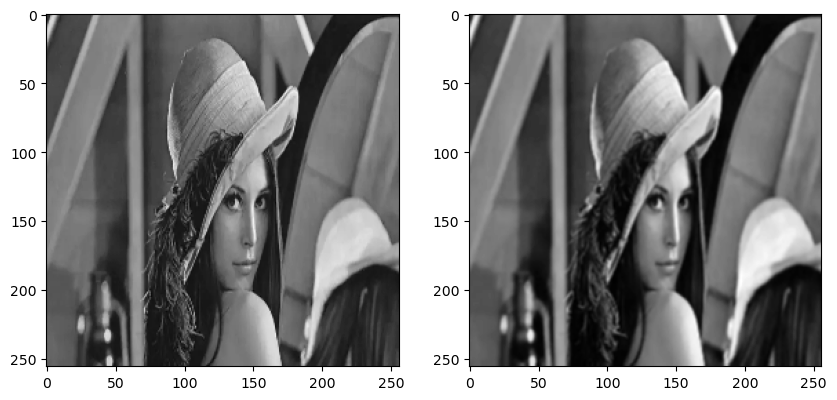

In [3]:
# ⼿动设置⼀个简单的⾼斯滤波器
kernel_gaussian = np.array([[1, 2, 1],
 [2, 4, 2],
 [1, 2, 1]])/16
# ⽤滤波器处理图像并预览
filtered = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_gaussian)
# 和原图拼在一起查看
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(img,cmap=plt.cm.gray)
plt.subplot(122)
plt.imshow(filtered,cmap=plt.cm.gray)

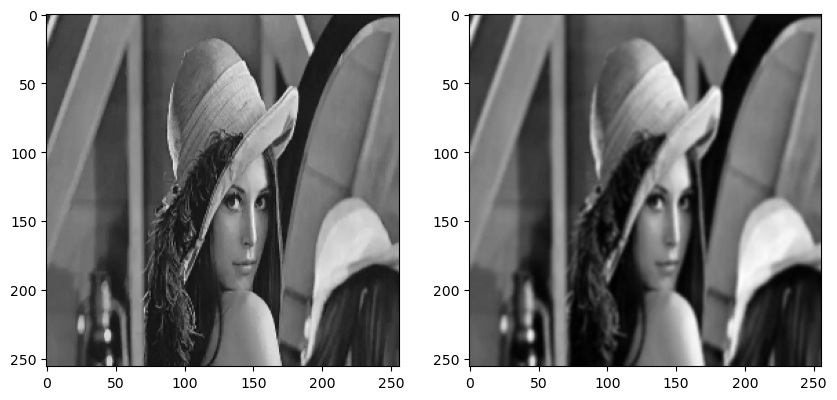

In [4]:
# ⼿动设置⼀个更⼤的⾼斯滤波
kernel_gaussian = np.array([[1, 4, 7, 4, 1],
                            [4,16,26,16, 4],
                            [7,26,41,26, 7],
                            [4,16,26,16, 4],
                            [1, 4, 7, 4, 1]])/273
filtered = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_gaussian)
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(img,cmap=plt.cm.gray)
plt.subplot(122)
plt.imshow(filtered,cmap=plt.cm.gray)

### 练习
编写⼀个⽣成⾼斯滤波器的函数。该函数输⼊两个参数：⾼斯滤波器的边⻓、标准差sigma。返回⾼斯滤波器数组。按照题中的参数，将结果存到lab4_result/exe_result_1.png中。

True

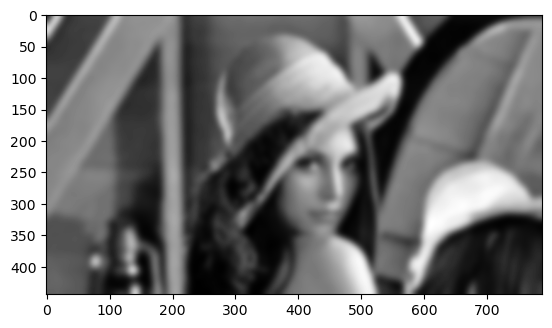

In [5]:

########################
#                      #
#    Exercise 1        #
#                      #
########################
# 替换下⾯的pass，完成gaussian_filter()函数
def gaussian_filter(kernel_size=3, sigma=1):
    """
    生成一个二维高斯滤波器核。

    参数:
    kernel_size (int): 滤波器核的大小。
    sigma (float): 高斯分布的标准差。

    返回:
    np.ndarray: 二维高斯滤波器核。
    """
    kx = cv2.getGaussianKernel(kernel_size, sigma)
    ky = cv2.getGaussianKernel(kernel_size, sigma)
    return np.outer(kx, ky)

# ⽤上⾯的gaussian_filter()函数创建⼀个⾃定义的⾼斯核，让其边⻓为30，标准差为5
kernel_size=30 # 边⻓
sigma = 5 # 标准差
custom_gaussian = gaussian_filter(kernel_size, sigma)
# ⽤⾃定义的⾼斯滤波器处理图像并预览
img = cv2.imread('lab4_img/lena.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
filtered = cv2.filter2D(src=img, ddepth=-1, kernel=custom_gaussian)
plt.imshow(filtered,cmap=plt.cm.gray)
cv2.imwrite('lab4_result/exe_result_1.png', filtered)

### Prewitt 滤波器

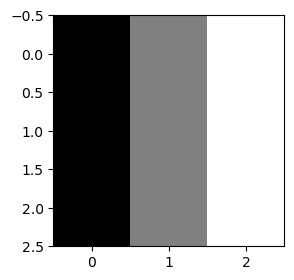

In [6]:
# ⼿动设置⼀个Prewitt⽔平梯度滤波器
kernel_prewitt1 = np.array([[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]])
# ⽤可视化查看
plt.figure(figsize=(3,3))
plt.imshow(kernel_prewitt1,cmap=plt.cm.gray)

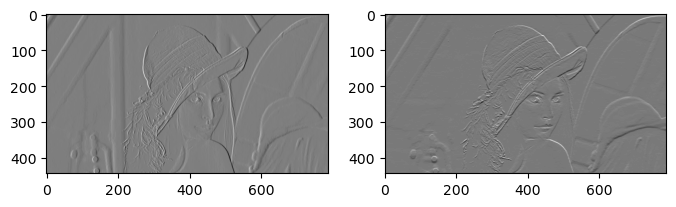

In [7]:
# Prewitt⽔平梯度滤波器检测的是竖直⽅向的边缘
filtered1 = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_prewitt1)
# 改变Prewitt的⽅向，设置垂直梯度的滤波器
kernel_prewitt2 = np.array([[-1, -1, -1],
 [0, 0, 0 ],
 [1, 1, 1 ]])
# ⽤可视化查看
# Prewitt垂直梯度滤波器检测的是⽔平⽅向的边缘
filtered2 = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_prewitt2)
plt.figure(figsize=(8,14))
plt.subplot(121)
plt.imshow(filtered1,cmap=plt.cm.gray)
plt.subplot(122)
plt.imshow(filtered2,cmap=plt.cm.gray)
plt.show()

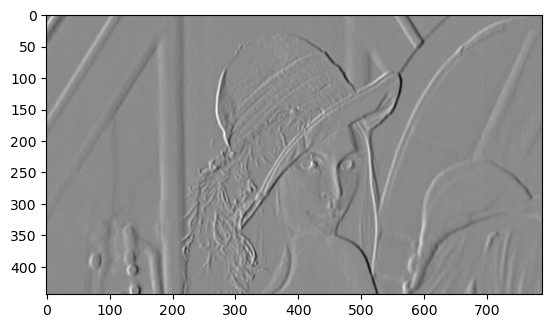

In [8]:
# 尺度更⼤的⽔平梯度滤波器
kernel_prewitt = np.array([[-2, -1, 0, 1, 2],
 [-2, -1, 0, 1, 2],
 [-2, -1, 0, 1, 2],
 [-2, -1, 0, 1, 2],
 [-2, -1, 0, 1, 2]])
filtered = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_prewitt)
plt.imshow(filtered,cmap=plt.cm.gray)

### ~~练习~~
编写⼀个函数，⽤于⾃定义Prewitt滤波器。它传⼊2个参数：
* 第1个参数为滤波器的边⻓。
* 第2参数为布尔值，当它为True时，输出⽔平梯度滤波器，当它为False时，输出垂直梯度滤波器。

In [9]:
def prewitt(kernel_size = 3, is_horizontal = True):
    pass
# 此题不计分，参考答案: 
def prewitt(kernel_size = 3, is_horizontal = True):
    """
    生成自定义的Prewitt滤波器。

    参数:
    kernel_size (int): 滤波器的边长，默认为3。
    is_horizontal (bool): 布尔值，为True时输出水平梯度滤波器，为False时输出垂直梯度滤波器，默认为True。

    返回:
    np.ndarray: 生成的Prewitt滤波器核。
    """
    # 初始化核
    kernel = np.zeros((kernel_size, kernel_size))
    # 计算中间索引
    center = kernel_size // 2
    if is_horizontal:
        # 水平梯度滤波器
        kernel[:, :center] = -1
        kernel[:, center+1:] = 1
    else:
        # 垂直梯度滤波器
        kernel[:center, :] = -1
        kernel[center+1:, :] = 1
    return kernel

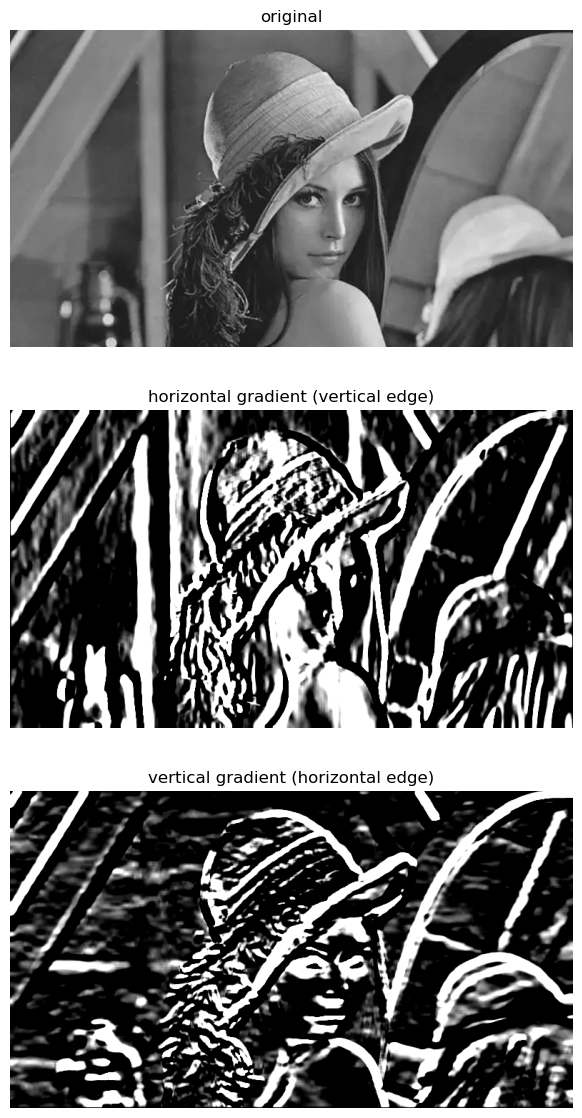

In [10]:
# 完成prewitt()后，运⾏下⾯的代码
# 利⽤prewitt函数，⾃定义⼀个边⻓为11的⽔平梯度滤波器，以及⼀个边⻓为11的垂直梯度滤波器
# 并对以下图像进⾏边缘检测
img_building = cv2.imread('lab4_img/lena.png')
img_building = cv2.cvtColor(img_building, cv2.COLOR_BGR2GRAY) 
prewitt_h = np.array(prewitt(11, True))
filtered_h = cv2.filter2D(src=img_building, ddepth=-1, kernel=prewitt_h)
prewitt_v = np.array(prewitt(11, False))
filtered_v = cv2.filter2D(src=img_building, ddepth=-1, kernel=prewitt_v)
fig, axes = plt.subplots(3, 1, figsize = (14,14))
plt.gray()
axes[0].imshow(img_building)
axes[1].imshow(filtered_h)
axes[2].imshow(filtered_v)
titles = ["original", "horizontal gradient (vertical edge)", "vertical gradient (horizontal edge)"]
for i, ax in enumerate(axes.ravel()):
 ax.set_title(titles[i])
 ax.axis("off")
plt.show()

### Sobel滤波器

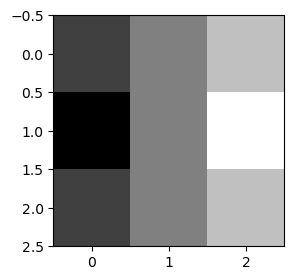

In [11]:
# ⼿动设置⼀个Sobel⽔平梯度滤波器
kernel_sobel = np.array([[-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]])
# ⽤可视化查看结果
plt.figure(figsize=(3,3))
plt.imshow(kernel_sobel,cmap=plt.cm.gray)

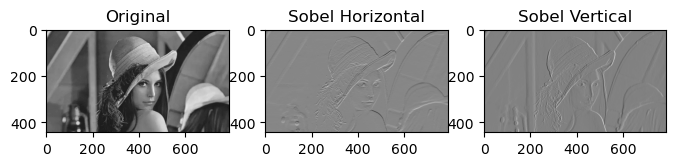

In [12]:
# 手动设置一个Sobel水平梯度滤波器
kernel_sobel_horizontal = np.array([[ 1, 2, 1],
                                    [ 0, 0, 0],
                                    [-1, -2, -1]])
# Sobel水平梯度滤波器检测的是垂直方向的边缘
filtered_horizontal = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_sobel_horizontal)

# 手动设置一个Sobel垂直梯度滤波器
kernel_sobel_vertical = np.array([[ 1, 0, -1],
                                  [ 2, 0, -2],
                                  [ 1, 0, -1]])
# Sobel垂直梯度滤波器检测的是水平方向的边缘
filtered_vertical = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_sobel_vertical)

plt.figure(figsize=(8,14))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(132)
plt.imshow(filtered_horizontal, cmap='gray')
plt.title('Sobel Horizontal')
plt.subplot(133)
plt.imshow(filtered_vertical, cmap='gray')
plt.title('Sobel Vertical')
plt.show()

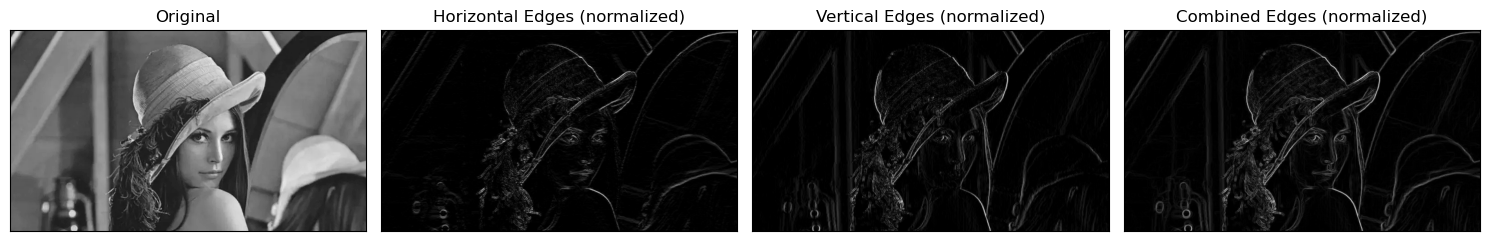

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 定义水平和垂直Sobel滤波器
kernel_sobel_h = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]])
kernel_sobel_v = np.array([[ 1, 2, 1],
                          [ 0, 0, 0],
                          [-1, -2, -1]])

# 分别滤波，提取相应方向的边缘
filtered_h = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_sobel_v)
filtered_v = cv2.filter2D(src=img, ddepth=-1, kernel=kernel_sobel_h)

# 转换为浮点数以避免计算梯度幅值时溢出
# 看幅值
filtered_h_float = np.abs(filtered_h.astype(np.float32))
filtered_v_float = np.abs(filtered_v.astype(np.float32))

# 计算梯度幅值
gradient_magnitude = np.sqrt(np.square(filtered_h_float) + np.square(filtered_v_float))

# 对所有结果进行归一化到0-255
filtered_h_norm = cv2.normalize(filtered_h_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
filtered_v_norm = cv2.normalize(filtered_v_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gradient_magnitude_norm = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 显示结果
plt.figure(figsize=(15, 5))

plt.subplot(141)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.xticks([]), plt.yticks([])

plt.subplot(142)
plt.imshow(filtered_h_norm, cmap='gray')
plt.title('Horizontal Edges (normalized)')
plt.xticks([]), plt.yticks([])

plt.subplot(143)
plt.imshow(filtered_v_norm, cmap='gray')
plt.title('Vertical Edges (normalized)')
plt.xticks([]), plt.yticks([])

plt.subplot(144)
plt.imshow(gradient_magnitude_norm, cmap='gray')
plt.title('Combined Edges (normalized)')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

#### 拆分2D卷积核为两个1D卷积核

In [14]:
# 定义第⼀组1D卷积核
sobel1_v = np.array([1,2,1])[:,None] #列
sobel1_h = np.array([-1,0,1])[None,:] #⾏
print(sobel1_v)
print(sobel1_h)
# 查看这两个1D卷积核的Kronecker积是否为Sobel滤波器
print("combined: ")
print(np.kron(sobel1_v, sobel1_h))

[[1]
 [2]
 [1]]
[[-1  0  1]]
combined: 
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


2D Sobel kernel:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
Maximum difference between methods: 0.0


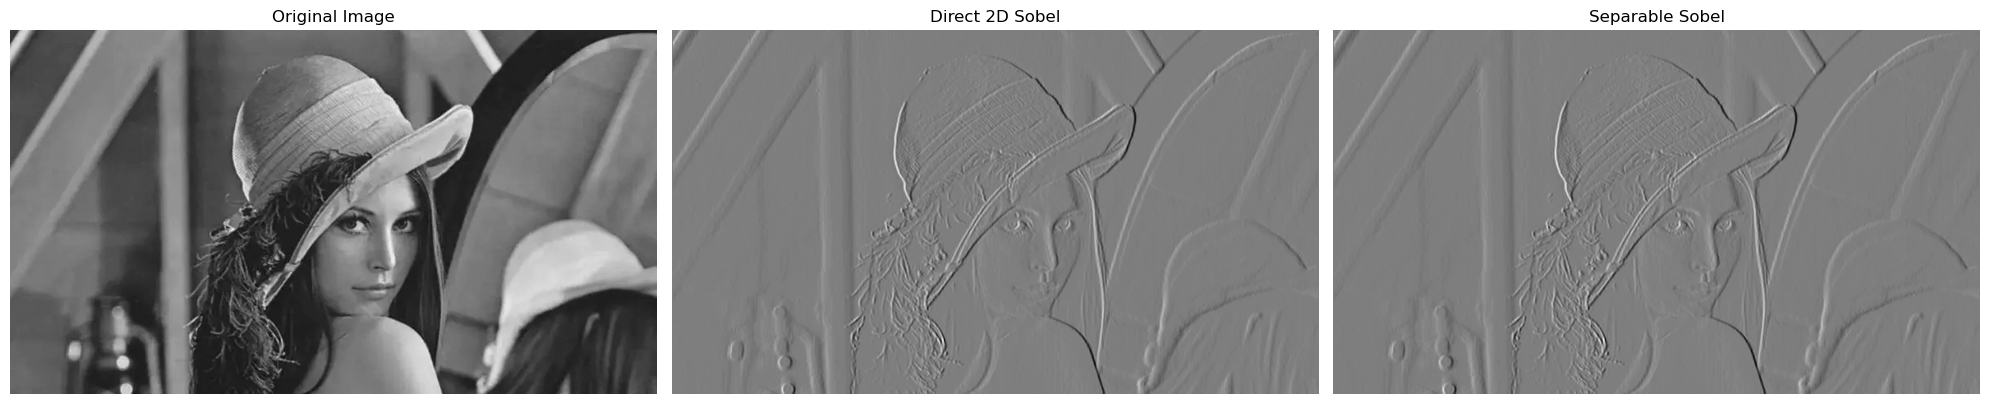

In [15]:
img_gray = img.astype(np.float32)
# 正确定义Sobel卷积核
# 垂直方向核 [1,2,1]^T
sobel_y = np.array([[1], [2], [1]], dtype=np.float32)  
# 水平方向核 [-1,0,1]
sobel_x = np.array([[-1, 0, 1]], dtype=np.float32)

# Sobel 2D核是这两个1D核的外积
sobel_2d = np.matmul(sobel_y, sobel_x)
print("2D Sobel kernel:")
print(sobel_2d)

# 方法1: 直接使用2D卷积
direct_result = cv2.filter2D(img_gray, -1, sobel_2d, borderType=cv2.BORDER_DEFAULT)

# 方法2: 使用可分离卷积 - 先垂直方向，再水平方向
# temp = cv2.filter2D(img_gray, -1, sobel_y, borderType=cv2.BORDER_DEFAULT)  
# separable_result = cv2.filter2D(temp, -1, sobel_x, borderType=cv2.BORDER_DEFAULT)
separable_result = cv2.sepFilter2D(img_gray, -1, sobel_x, sobel_y, borderType=cv2.BORDER_DEFAULT)
# 计算差异
diff = np.abs(direct_result - separable_result)
max_diff = np.max(diff)
print(f"Maximum difference between methods: {max_diff}")

# 显示结果
plt.figure(figsize=(20, 5))

plt.subplot(131)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(cv2.normalize(direct_result, None, 0, 255, cv2.NORM_MINMAX), cmap='gray')
plt.title('Direct 2D Sobel')
plt.axis('off')

plt.subplot(133)
plt.imshow(cv2.normalize(separable_result, None, 0, 255, cv2.NORM_MINMAX), cmap='gray')
plt.title('Separable Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
import time

# 定义Sobel卷积核
# 垂直方向核 (11x1)
sobel_y = np.array([-1,-2,-3,-4,-5,0,5,4,3,2,1], dtype=np.float32)[:,None]

# 水平方向核 (1x11)  
sobel_x = np.array([-1,-2,-3,-4,-5,0,5,4,3,2,1], dtype=np.float32)[None,:]

sobel_2d = np.matmul(sobel_y, sobel_x)


iterations = 1000
start_time = time.time()
for _ in range(iterations):
    direct_result = cv2.filter2D(img_gray, -1, sobel_2d, borderType=cv2.BORDER_DEFAULT)
direct_time = time.time() - start_time
print(f"2D convolution time for {iterations} iterations: {direct_time:.4f} seconds")

# 进行1000次操作，测量分离卷积时间
start_time = time.time()
for _ in range(iterations):
    # temp = cv2.filter2D(img_gray, -1, sobel_y, borderType=cv2.BORDER_DEFAULT)
    # separable_result = cv2.filter2D(temp, -1, sobel_x, borderType=cv2.BORDER_DEFAULT)
    separable_result = cv2.sepFilter2D(img_gray, -1, sobel_x, sobel_y, borderType=cv2.BORDER_DEFAULT)
separable_time = time.time() - start_time
print(f"Separable convolution time for {iterations} iterations: {separable_time:.4f} seconds")

# 计算加速比
speedup = direct_time / separable_time
print(f"Speedup factor: {speedup:.2f}x")

2D convolution time for 1000 iterations: 1.3141 seconds
Separable convolution time for 1000 iterations: 0.6515 seconds
Speedup factor: 2.02x


## 4.2 图像金字塔

### 练习
编写降采样函数downsampling()，它传⼊⼀张灰度图⽚，输出1/4尺度的机械降采样结果，采样⽅式如果下图所示，即每4个像素中，保留左上⽅的⼀个像素。
![降采样图示](lab4_img/downsample.png)


In [17]:
########################
#                      #
#    Exercise 3        #
#                      #
########################

# 替换下⾯的pass，完成函数
def downsampling(img):
    height, width = img.shape

    new_height = height //2
    new_width = width //2

    downsampled_img = np.zeros((new_height, new_width), dtype=img.dtype)

    for i in range(new_height):
        for j in range(new_width):
            downsampled_img[i, j] = img[i*2, j*2]

    return downsampled_img

### ~~练习~~
编写机械降采样图像⾦字塔的函数raw_pyramid()。
* 输⼊2个参数：图⽚、降采样次数（factor）
* 输出⼀个数组，⾥⾯包含原图，以及⾦字塔每⼀层的图⽚
* 报错：如果下采样次数过多，导致输出图像边⻓<10，报错“下采样次数过多”

In [18]:

# def raw_pyramid(img, factor):
#  pass
# 直接给出答案，供参考
def raw_pyramid(img, factor):
    """
    生成机械降采样图像金字塔。

    参数:
    img (np.ndarray): 输入的图像。
    factor (int): 降采样次数。

    返回:
    list: 包含原图和金字塔每一层图片的数组。

    报错:
    如果下采样次数过多，导致输出图像边长 < 10，抛出 ValueError 异常。
    参考答案：ans_hw0右侧图
    """
    pyramid = [img]
    current_img = img
    for _ in range(factor):
        # 调用之前的降采样函数
        current_img = downsampling(current_img)
        if current_img.shape[0] < 10 or current_img.shape[1] < 10:
            raise ValueError("下采样次数过多")
        pyramid.append(current_img)
    return pyramid


### 作业
编写组建⾼斯⾦字塔及拉普拉斯⾦字塔的函数gaussian_pyramid()
* 输⼊参数：图⽚、降采样次数（factor），⾼斯核
* 输出⼀个数组，⾥⾯包含两个数组，第⼀个为⾼斯⾦字塔的各层图像（包括原图），第⼆个为拉普拉斯⾦字塔的各层图像
* 报错1：如果下采样次数过多，导致输出图像边⻓<10，报错“下采样次数过多”
* 报错2：如果下采样次数过多，导致输出图像边⻓<⾼斯核边⻓，报错“下采样次数过多”

In [33]:
import numpy as np
from scipy.signal import convolve2d
########################
#                      #
#    Homework 1        #
#                      #
########################
def gaussian_pyramid(img, factor, kernel):
    """
    组建高斯金字塔及拉普拉斯金字塔。

    参数:
    img (np.ndarray): 输入的图片。
    factor (int): 降采样次数。
    kernel (np.ndarray): 高斯核。

    返回:
    list: 包含两个数组，第一个为高斯金字塔的各层图像（包括原图），第二个为拉普拉斯金字塔的各层图像。

    报错:
    如果下采样次数过多，导致输出图像边长 < 10 或边长 < 高斯核边长，抛出 ValueError 异常。
    """
    h, w = img.shape
    kernel_size = kernel.shape[0]

    final_h = h // (2**factor)
    final_w = w // (2**factor)

    if final_h < 10 or final_w < 10:
        raise ValueError('下采样次数过多')
    if final_h < kernel_size or final_w < kernel_size:
        raise ValueError('下采样次数过多')
    
    gaussian_pyr = [img.copy()]
    laplcian_pyr = []

    current = img.copy()
    for _ in range(factor):
        blurred = convolve2d(current, kernel, mode='same', boundary='symm')
        downsampled = blurred[::2, ::2]
        gaussian_pyr.append(downsampled)

        upsampled = np.zeros(current.shape)
        upsampled[::2, ::2] = downsampled

        upsampled_blurred =  convolve2d(upsampled, kernel*4, mode='same', boundary='symm')
        laplacian = current - upsampled_blurred
        laplcian_pyr.append(laplacian)

        current = downsampled
    
    return [gaussian_pyr, laplcian_pyr]

完成以上三个函数的编写后，运⾏下⾯的代码，查看⾼斯⾦字塔和机械降采样⾦字塔的效果对⽐。参考答案：ans_hw0.png

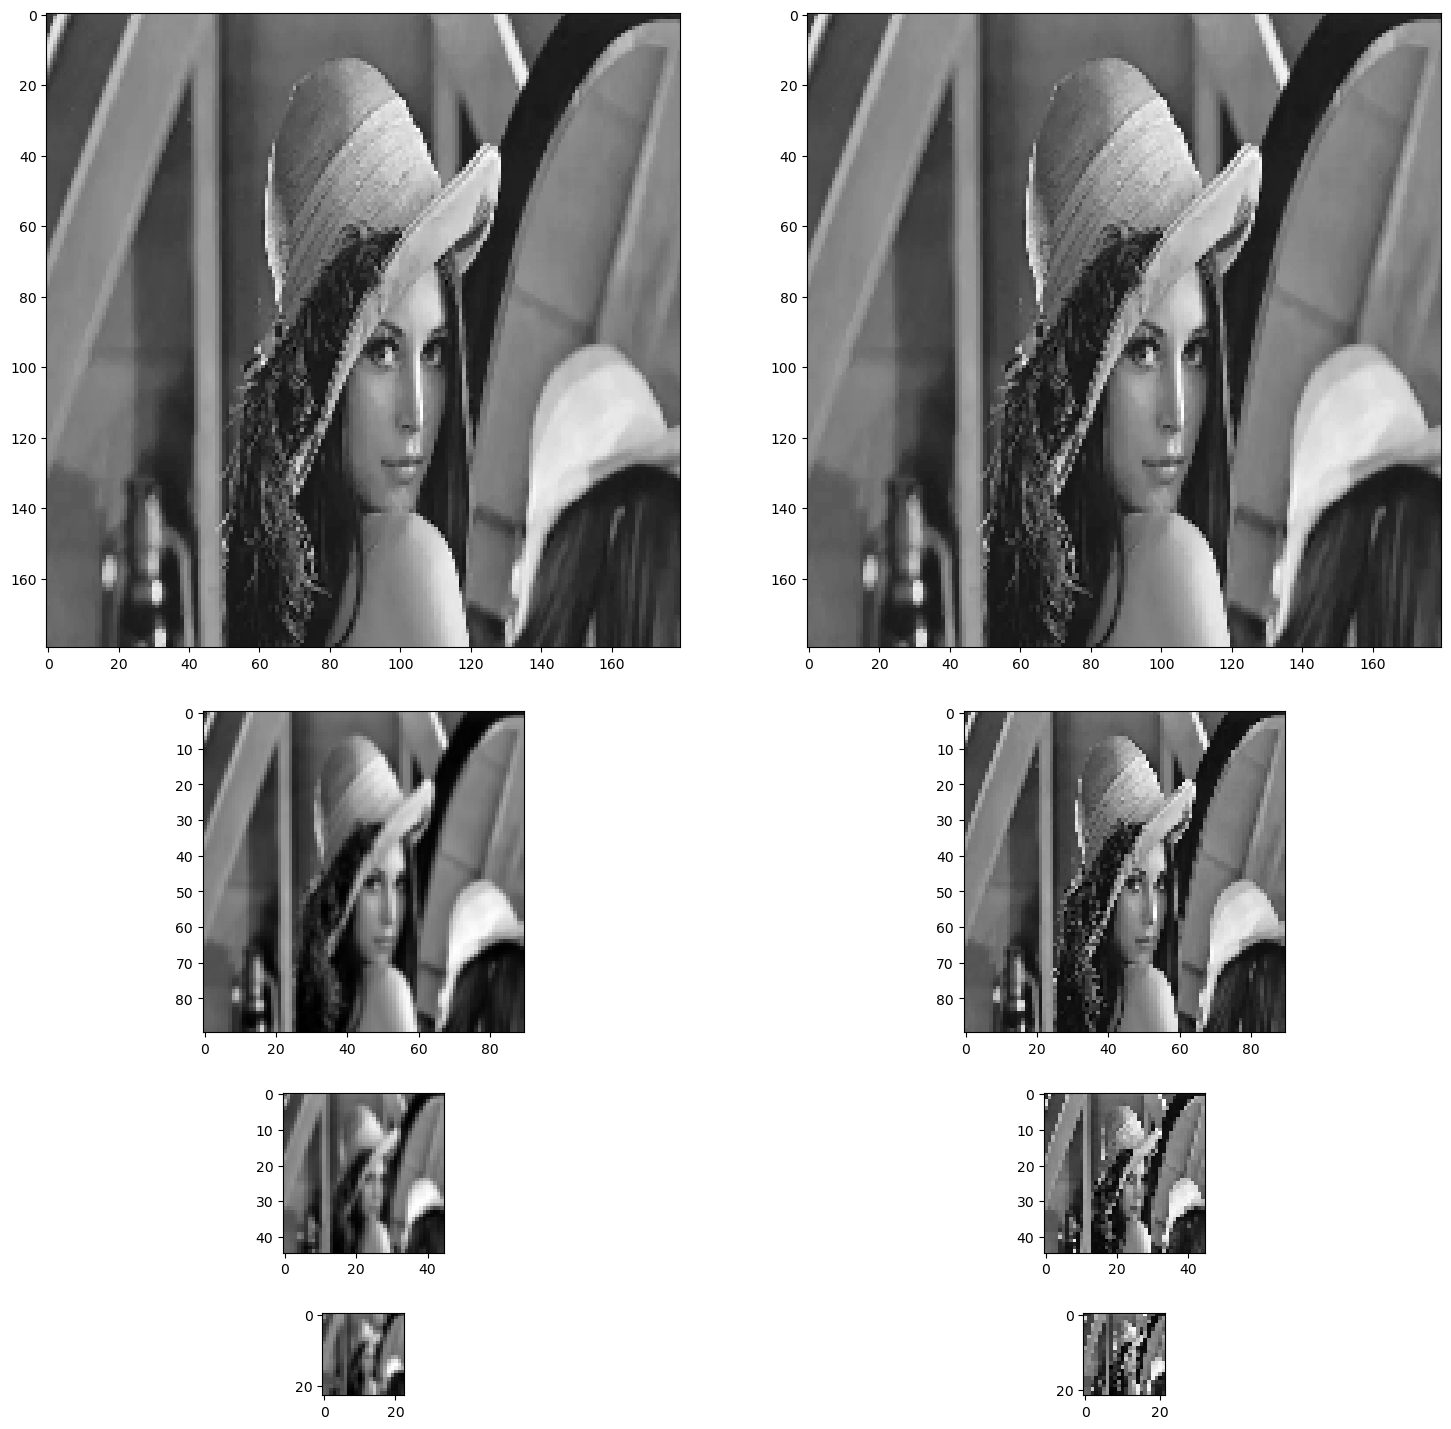

In [23]:
# 导⼊示例图⽚、灰度化、重设宽和⾼、查看图⽚
img = cv2.imread('lab4_img/lena.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
img = cv2.resize(img, (180, 180), 
interpolation = cv2.INTER_LINEAR)
# ⽤前⾯的guassian_filter函数定义⼀个⾼斯核
kernel = gaussian_filter(9, 1)
# 创建⼀个⾼斯⾦字塔及拉普拉斯⾦字塔（下采样操作次数为3，共4层）
gaussian_py = gaussian_pyramid(img, 3, kernel)[0]
# 创建⼀个普通的机械降采样⾦字塔
normal_py = raw_pyramid(img, 3)
# 计算每⼀层图像的⼤⼩
size = []
for i in gaussian_py:
 size.append(i.shape[0])
 
fig, axes = plt.subplots(len(gaussian_py), 2, figsize = (18,18), gridspec_kw={'height_ratios': size})
plt.gray()
for i in range(len(gaussian_py)):
 axes[i][0].imshow(gaussian_py[i])
 axes[i][1].imshow(normal_py[i])
plt.show()

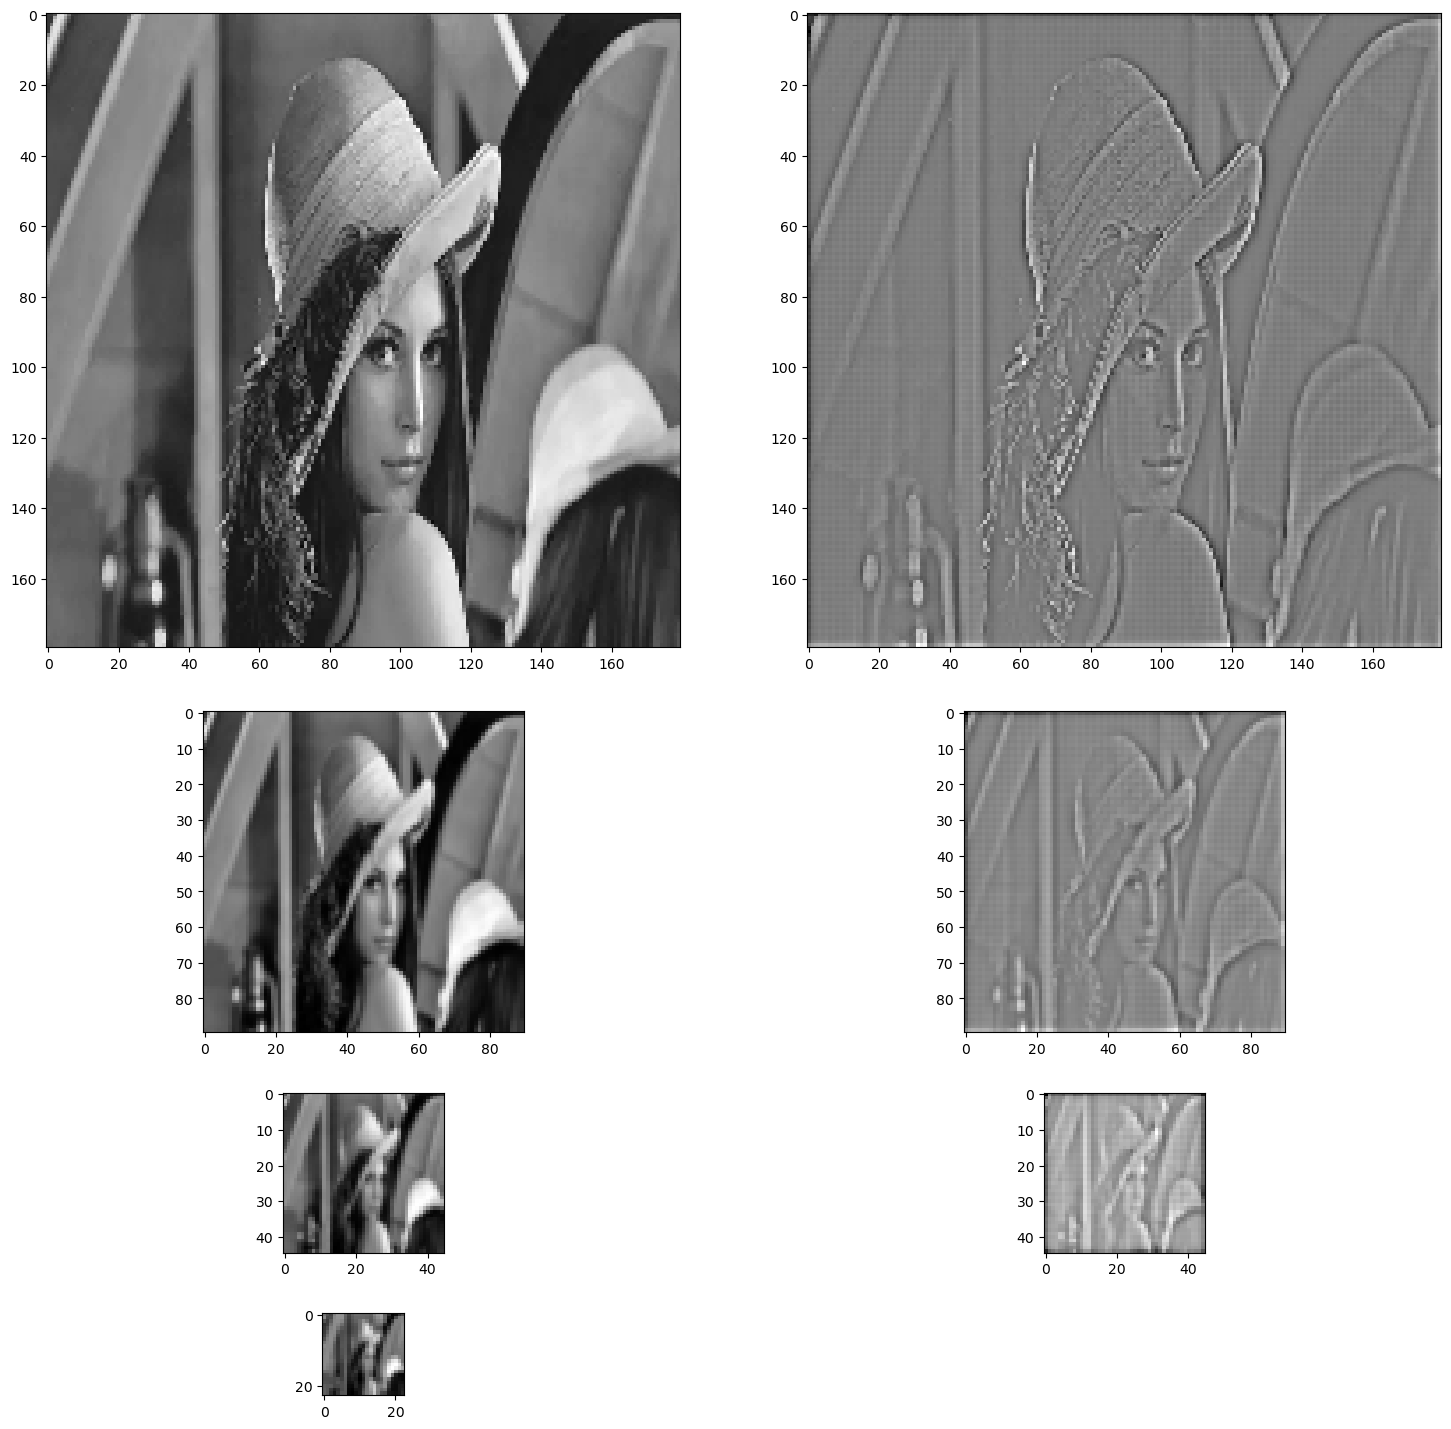

In [34]:
# ⽤前⾯的guassian_filter函数定义⼀个⾼斯核
kernel = gaussian_filter(9, 1)
# 创建⼀个⾼斯⾦字塔及拉普拉斯⾦字塔
gaussian_py = gaussian_pyramid(img, 3, kernel)[0]
laplacian_py = gaussian_pyramid(img, 3, kernel)[1]
# 计算每⼀层图像的⼤⼩
size = []
for i in gaussian_py:
 size.append(i.shape[0])
 
fig, axes = plt.subplots(len(gaussian_py), 2, figsize = (18,18), gridspec_kw={'height_ratios': size})
plt.gray()
for i in range(len(laplacian_py)):
 axes[i][0].imshow(gaussian_py[i])
 axes[i][1].imshow(laplacian_py[i])
# 拉普拉斯⾦字塔少⼀层，因此⾼斯⾦字塔需要再加⼀层
axes[len(gaussian_py)-1][0].imshow(gaussian_py[len(gaussian_py)-1])
plt.axis('off') 
plt.show()
# 参考答案：ans_hw.png